In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import copernicusmarine

# Download data

In [7]:
# copernicusmarine.subset(
#     dataset_id="METOFFICE-GLO-SST-L4-REP-OBS-SST",
#     variables=["analysed_sst"],
#     minimum_longitude=-5.0,
#     maximum_longitude=36.0,
#     minimum_latitude=30.0,
#     maximum_latitude=46.0,
#     start_datetime="2022-01-01T00:00:00",
#     end_datetime="2022-03-31T23:59:59",
#     output_directory="/work3/anscha/MyWorkspace/Post Doc/Teaching/25340 Digital Ocean/data/",
#     output_filename="mediterranean_sst_daily_2022.nc",
#     force_download=True
# )

WARNING - 2026-03-10T09:58:29Z - 'force_download' has been deprecated.
INFO - 2026-03-10T09:58:29Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  achauhan1


Copernicus Marine password:

  ········


INFO - 2026-03-10T09:58:40Z - Selected dataset version: "202003"
INFO - 2026-03-10T09:58:40Z - Selected dataset part: "default"
INFO - 2026-03-10T09:58:42Z - Starting download. Please wait...


  0%|          | 0/107 [00:00<?, ?it/s]

INFO - 2026-03-10T09:58:51Z - Successfully downloaded to /work3/anscha/MyWorkspace/Post Doc/Teaching/25340 Digital Ocean/data/mediterranean_sst_daily_2022.nc


ResponseSubset(file_path=PosixPath('/work3/anscha/MyWorkspace/Post Doc/Teaching/25340 Digital Ocean/data/mediterranean_sst_daily_2022.nc'), output_directory=PosixPath('/work3/anscha/MyWorkspace/Post Doc/Teaching/25340 Digital Ocean/data'), filename='mediterranean_sst_daily_2022.nc', file_size=45.081702290076336, data_transfer_size=1440.7914503816794, variables=['analysed_sst'], coordinates_extent=[GeographicalExtent(minimum=-4.974999904632568, maximum=35.974998474121094, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=30.024999618530273, maximum=45.974998474121094, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2022-01-01T00:00:00+00:00', maximum='2022-03-31T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

# Data Ingestion and Inspection

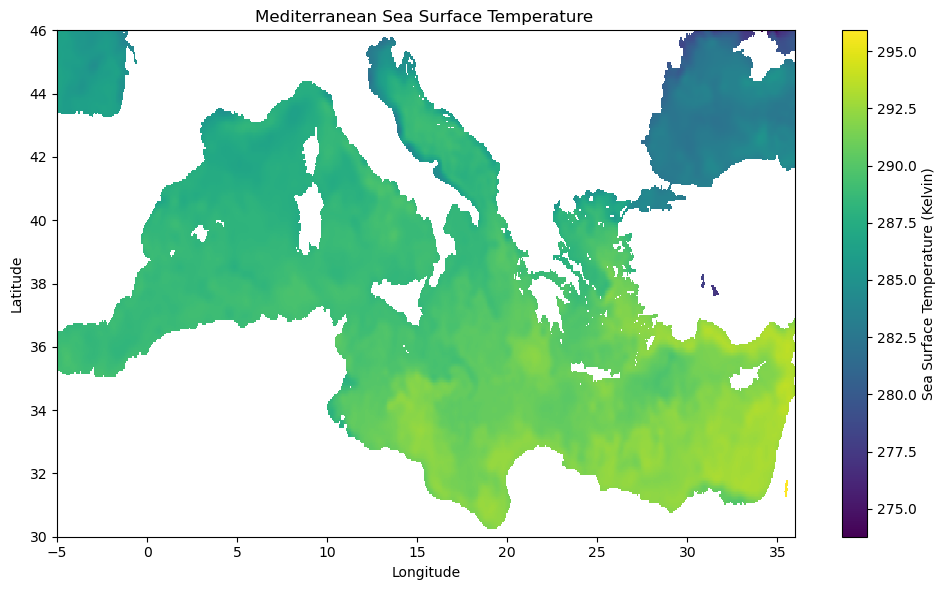

In [5]:
import xarray as xr
import matplotlib.pyplot as plt

# Load the newly downloaded dataset

#### To do #####
## add path here
file_path = " " 
###############

ds = xr.open_dataset(file_path)

# Extract a single time slice
sst_day_one = ds['analysed_sst'].isel(time=0)

# Create the plot
plt.figure(figsize=(10, 6))

# xarray's built-in plot wrapper automatically handles coordinates and colorbars
sst_day_one.plot(
    cmap='viridis', # Use 'viridis' as it is perceptually uniform and colorblind-friendly
    cbar_kwargs={'label': 'Sea Surface Temperature (Kelvin)'} 
)

# Formatting
plt.title("Mediterranean Sea Surface Temperature ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

# Display the plot
plt.show()

# Temporal Aggregation (Daily to Monthly)

Original time steps (Daily): 90
Aggregated time steps (Monthly): 3


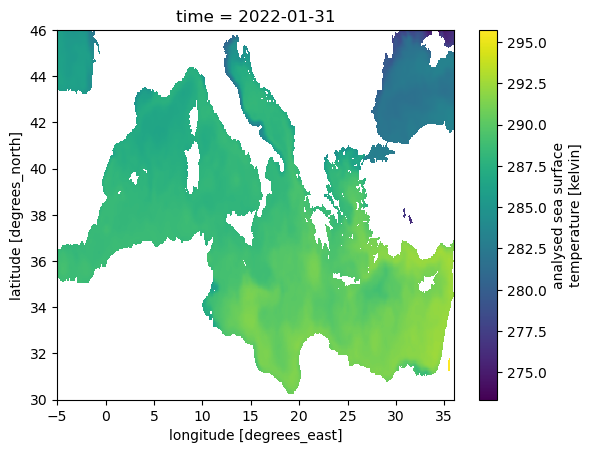

In [11]:
# Print the original time dimension length
print(f"Original time steps (Daily): {len(ds['time'])}")

# Resample the data to a monthly frequency ('1ME' = Month End) and calculate the mean

#### To do #####
# try different functions such as mean, median, max, min
# try different frequencies on time such as  1D, 6H, 1YS
ds_monthly = ds.resample(time='1ME').mean()  # .resample() is strictly for time-series data
###############

# Print the new time dimension length
print(f"Aggregated time steps (Monthly): {len(ds_monthly['time'])}")

ds_monthly['analysed_sst'].isel(time=0).plot(cmap='viridis')
plt.show()

# Spatial Downscaling (Coarsening)

Original Spatial Resolution:
Latitude: 320, Longitude: 820

Coarsened Spatial Resolution:
Latitude: 80, Longitude: 205


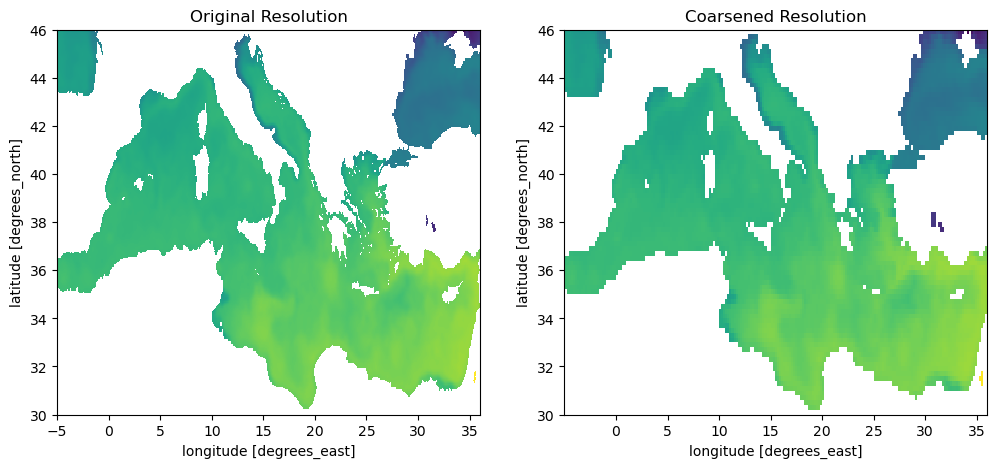

In [5]:
# Check original spatial dimensions
print("Original Spatial Resolution:")
print(f"Latitude: {len(ds_monthly['latitude'])}, Longitude: {len(ds_monthly['longitude'])}")

# Coarsen the grid by a chosen factor (for instance, 2 or 4) in both spatial dimensions.
# boundary='trim' to to drop the leftover edge pixels
#### To do #####
# try different factors for lat and lon
ds_coarse = ds_monthly.coarsen(latitude=4, longitude=4, boundary='trim').mean()  # .resample() is strictly for time-series data
###############

# Check new spatial dimensions (should be approximately half the original size)
print("\nCoarsened Spatial Resolution:")
print(f"Latitude: {len(ds_coarse['latitude'])}, Longitude: {len(ds_coarse['longitude'])}")

# Optional visual comparison for the students
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
ds_monthly['analysed_sst'].isel(time=0).plot(add_colorbar=False)
plt.title("Original Resolution")
plt.subplot(1, 2, 2)
ds_coarse['analysed_sst'].isel(time=0).plot(add_colorbar=False)
plt.title("Coarsened Resolution")
plt.show()

# Masking (Creating and Applying a Boolean Mask)

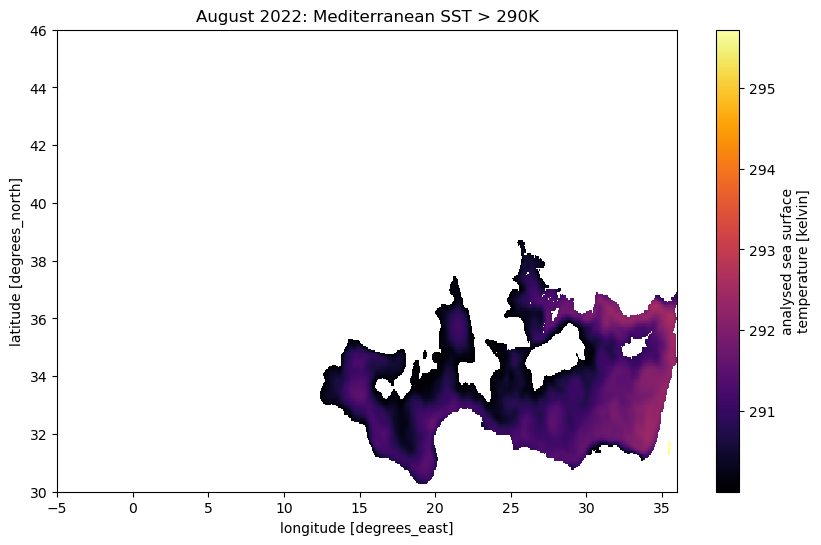

In [6]:
# 1. Create a boolean mask condition (True/False)
#### To do #####
# try different values for temperature and see how mask is changing
warm_water_mask = ds_monthly['analysed_sst'] > 290.0
###############

# 2. Apply the mask using .where()
ds_masked = ds_monthly.where(warm_water_mask)

# 3. Quick visual check of a summer month (e.g., August, index 7)
plt.figure(figsize=(10, 6))
ds_masked['analysed_sst'].isel(time=0).plot(cmap='inferno')
plt.title("August 2022: Mediterranean SST > 290K")
plt.show()

# Handling Missing Values (Fixing Gaps)

Injecting artificial gaps on: ['2022-02-10', '2022-02-11']
Total missing days currently in dataset: 2


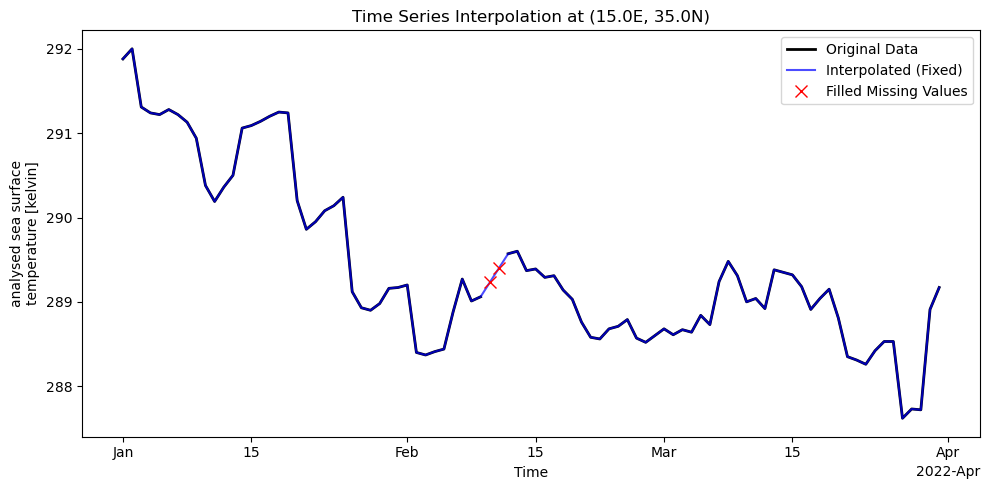

In [8]:
# 1. Isolate a single point and load it into memory
# Pick a specific coordinate (e.g., Central Mediterranean)
lon_point, lat_point = 15.0, 35.0 
ds_ts = ds['analysed_sst'].sel(longitude=lon_point, latitude=lat_point, method='nearest').copy(deep=True)

# 2. INJECT GAPS: Define your list of dates to erase
#### To do #####
# Try changing these dates, adding more, or making them non-consecutive, then re-run!
missing_dates = ['2022-02-10', '2022-02-11'] 
###############

print(f"Injecting artificial gaps on: {missing_dates}")

# Apply the NaNs
ds_ts.loc[dict(time=missing_dates)] = np.nan

# Verify the gap exists
missing_count = ds_ts.isnull().sum().values
print(f"Total missing days currently in dataset: {missing_count}")

ds_filled = ds_ts.interpolate_na(dim='time', method='linear', limit=3)

# 4. Visual Proof
# Since ds_ts is already a 1D time series for our specific point, we can plot it directly.
plt.figure(figsize=(10, 5))

# Plot the broken data with markers to show the gap
ds_ts.plot(label='Original Data', color='black', linewidth=2)
ds_filled.plot(label='Interpolated (Fixed)', color='blue', alpha=0.7)

# Dynamically find all timestamps where the original data is NaN
missing_dates = ds_ts.time[ds_ts.isnull()].values

# Isolate the timestamps where data was originally missing
missing_dates = ds_ts.time[ds_ts.isnull()]
filled_points = ds_filled.sel(time=missing_dates)

# Plot the 'X' markers only on the newly generated data points
filled_points.plot(
    marker='x', 
    markersize=8, 
    color='red', 
    linestyle='none', # Crucial: no lines, just the markers
    label='Filled Missing Values'
)

plt.title(f"Time Series Interpolation at ({lon_point}E, {lat_point}N)")
plt.legend()
plt.tight_layout()
plt.show()